In [3]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Calculate the date range: 7 days ago to 3 days ago (to include April 24, 2025)
start_date = (datetime.today() - timedelta(days=10)).strftime('%Y-%m-%d')
end_date = (datetime.today() - timedelta(days=3)).strftime('%Y-%m-%d')  # to ensure April 24 is included

# Download NIFTY 50 data for the last 7 days (daily)
nifty = yf.download('^NSEI', start=start_date, end=end_date)

# Save data to CSV
nifty.to_csv('nifty_last_week.csv')
print("✅ Last week's data saved to nifty_last_week.csv")


[*********************100%***********************]  1 of 1 completed

✅ Last week's data saved to nifty_last_week.csv


In [6]:
import pandas as pd

# Load the data (adjust the file name if needed)
df = pd.read_csv('nifty_last_week.csv')

# Step 1: Check column names
print(df.columns)  # To see the exact column names and identify any inconsistencies

# Step 2: Clean the data
# Rename columns to remove extra spaces and ensure consistency in capitalization
df.rename(columns=lambda x: x.strip().capitalize(), inplace=True)

# Step 3: Handle missing data
df.dropna(inplace=True)  # Drop any rows with missing data

# Step 4: Convert the 'Date' column (or 'Datetime' if it's named differently) to datetime format
# Ensure the correct column name is used based on the output from df.columnsdf.to_csv('nifty_last_week_cleaned.csv', index=False
df.to_csv('nifty_last_week_cleaned.csv', index=False)

print("✅ Cleaned data saved to nifty_last_week_cleaned.csv")


Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
✅ Cleaned data saved to nifty_last_week_cleaned.csv


In [10]:
import pandas as pd

# Load the cleaned data
df = pd.read_csv('nifty_last_week_cleaned.csv')

# Print column names to identify the exact name of the date column
print(df.columns)


Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [14]:
import pandas as pd

# Load the cleaned data
df = pd.read_csv('nifty_last_week_cleaned.csv')

# Print column names
print(df.columns)


Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [16]:
import pandas as pd

# Load the cleaned data
df = pd.read_csv('nifty_last_week_cleaned.csv')

# Print the first few rows to inspect the data
print(df.head())


        Price           Close             High              Low  \
0      Ticker           ^NSEI            ^NSEI            ^NSEI   
1  2025-04-21  24125.55078125   24189.55078125  23903.650390625   
2  2025-04-22        24167.25  24242.599609375          24072.0   
3  2025-04-23  24328.94921875   24359.30078125   24119.94921875   
4  2025-04-24  24246.69921875  24347.849609375  24216.150390625   

              Open  Volume  
0            ^NSEI   ^NSEI  
1  23949.150390625  406100  
2  24185.400390625  440900  
3  24357.599609375  415000  
4  24277.900390625  358800  


In [17]:
import pandas as pd

# 1. Read the raw CSV, telling pandas that the first two rows are a MultiIndex header
df = pd.read_csv('nifty_last_week.csv', header=[0,1], index_col=0)

# 2. Flatten the column names (take just the top‐level labels, strip spaces & capitalize)
df.columns = [col[0].strip().capitalize() for col in df.columns]

# 3. Convert the index (which is your date) to actual datetime
df.index = pd.to_datetime(df.index)
df.index.name = 'Date'

# 4. Drop any rows with missing data
df.dropna(inplace=True)

# 5. Save out a clean, single‐header CSV
df.reset_index().to_csv('nifty_last_week_cleaned.csv', index=False)

print("✅ Cleaned data saved to nifty_last_week_cleaned.csv")
print(df.head())


✅ Cleaned data saved to nifty_last_week_cleaned.csv
                   Close          High           Low          Open  Volume
Date                                                                      
2025-04-21  24125.550781  24189.550781  23903.650391  23949.150391  406100
2025-04-22  24167.250000  24242.599609  24072.000000  24185.400391  440900
2025-04-23  24328.949219  24359.300781  24119.949219  24357.599609  415000
2025-04-24  24246.699219  24347.849609  24216.150391  24277.900391  358800


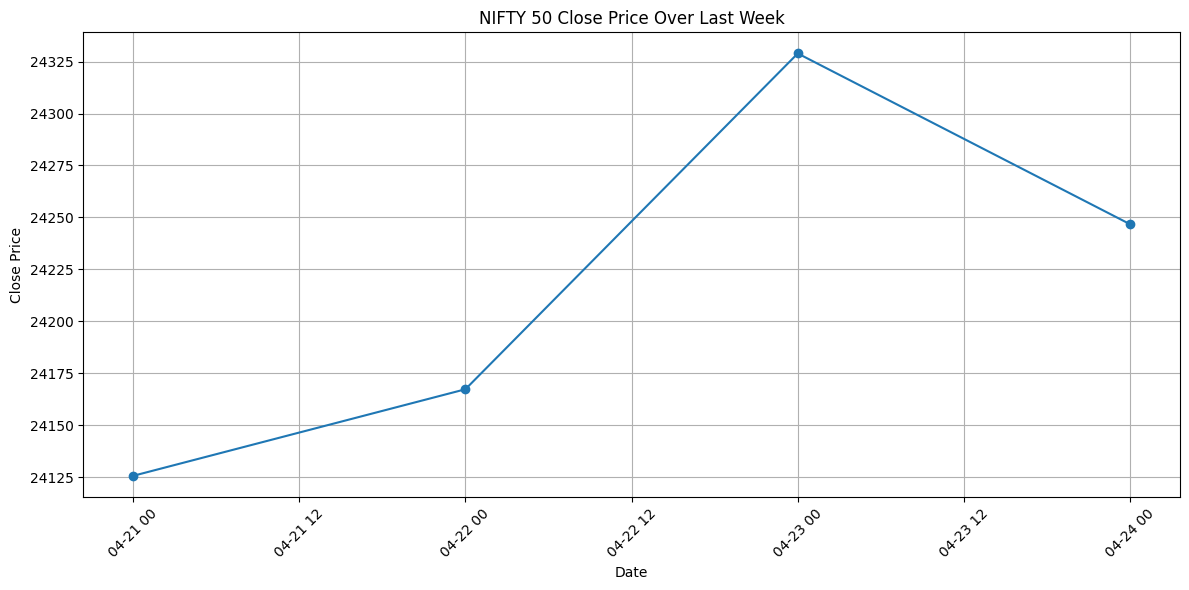

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned data, parsing the Date column
df = pd.read_csv('nifty_last_week_cleaned.csv', parse_dates=['Date'])

# 2. (Optional) Sort by Date just to be safe
df.sort_values('Date', inplace=True)

# 3. Plot the Line Chart: Close Price vs Date
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], marker='o', linestyle='-')
plt.title('NIFTY 50 Close Price Over Last Week')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


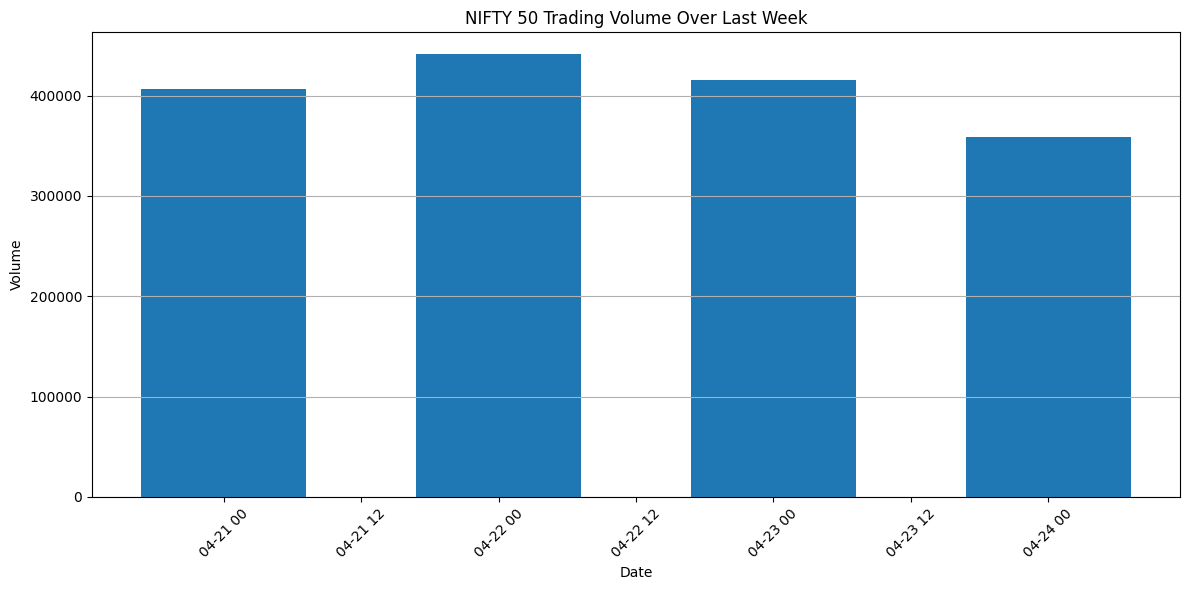

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned data, parsing the Date column
df = pd.read_csv('nifty_last_week_cleaned.csv', parse_dates=['Date'])

# 2. Sort by date to ensure correct order
df.sort_values('Date', inplace=True)

# 3. Plot the Bar Chart: Volume vs Date
plt.figure(figsize=(12, 6))
plt.bar(df['Date'], df['Volume'], width=0.6)
plt.title('NIFTY 50 Trading Volume Over Last Week')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


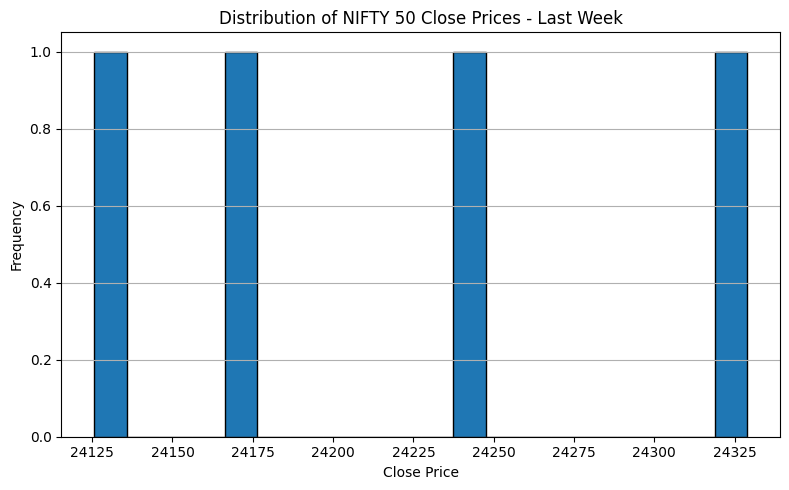

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned data, parsing the Date column
df = pd.read_csv('nifty_last_week_cleaned.csv', parse_dates=['Date'])

# 2. Plot the Histogram: Distribution of Close Prices
plt.figure(figsize=(8, 5))
plt.hist(df['Close'], bins=20, edgecolor='black')
plt.title('Distribution of NIFTY 50 Close Prices - Last Week')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


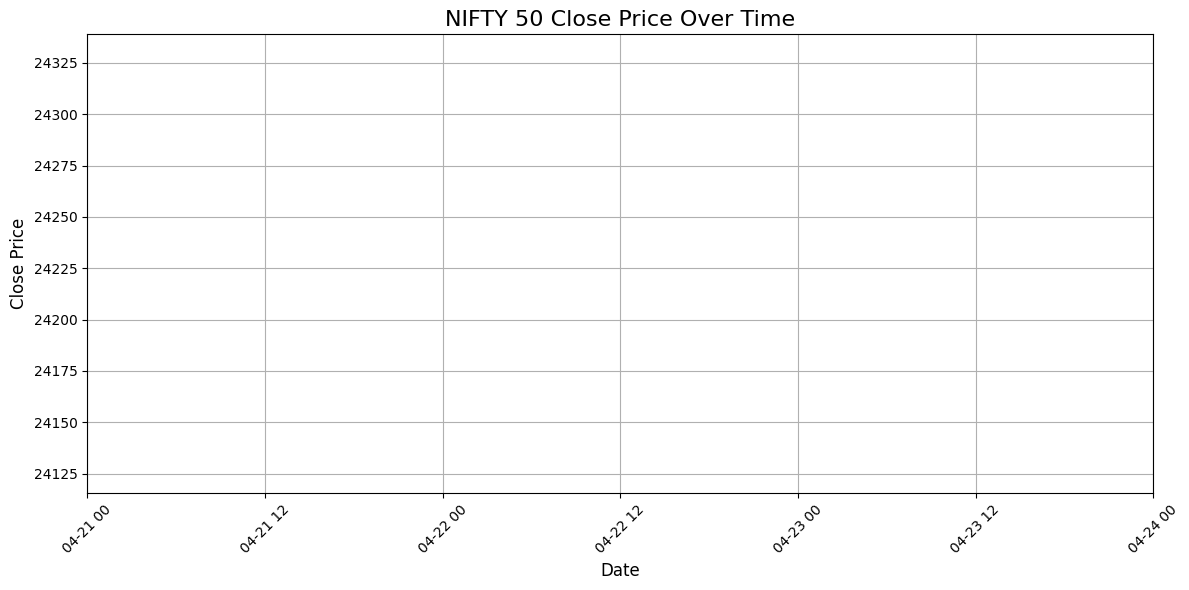

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Load the cleaned data, parsing the Date column
df = pd.read_csv('nifty_last_week_cleaned.csv', parse_dates=['Date'])

# 2. Sort by Date to ensure correct order
df.sort_values('Date', inplace=True)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('NIFTY 50 Close Price Over Time', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price', fontsize=12)
ax.grid(True)

# Line object for the animated plot with a color and marker style
line, = ax.plot([], [], color='darkorange', marker='o', markersize=5, linewidth=2)

# Set the limits for the plot
ax.set_xlim(df['Date'].min(), df['Date'].max())
ax.set_ylim(df['Close'].min() - 10, df['Close'].max() + 10)

# Initialization function (sets the background of the plot)
def init():
    line.set_data([], [])
    return line,

# Update function (updates the data of the line plot for each frame)
def update(frame):
    line.set_data(df['Date'][:frame], df['Close'][:frame])
    return line,

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(df), init_func=init, blit=True, interval=300)

# Display the animation
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


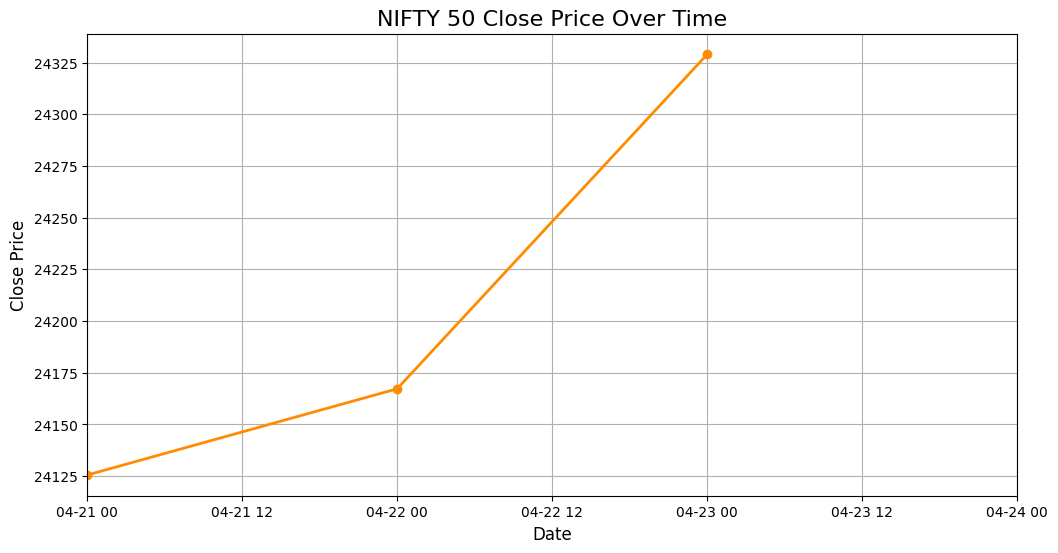

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Load and prepare
df = pd.read_csv('nifty_last_week_cleaned.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('NIFTY 50 Close Price Over Time', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price', fontsize=12)
ax.grid(True)

line, = ax.plot([], [], color='darkorange', marker='o', linewidth=2)

ax.set_xlim(df['Date'].min(), df['Date'].max())
ax.set_ylim(df['Close'].min() - 10, df['Close'].max() + 10)

def init():
    line.set_data([], [])
    return (line,)

def update(i):
    line.set_data(df['Date'][:i], df['Close'][:i])
    return (line,)

ani = animation.FuncAnimation(
    fig, update, frames=len(df), init_func=init,
    blit=True, interval=300
)

# This will embed the animation right in your notebook:
HTML(ani.to_jshtml())


In [29]:
# (continuing from the same fig/ani setup above)

# You need pillow for GIF support:
# pip install pillow

ani.save('nifty_animation.gif', writer='pillow', fps=2)
print("Saved animation to nifty_animation.gif")


Saved animation to nifty_animation.gif


✅ Saved animation to nifty_animation.gif


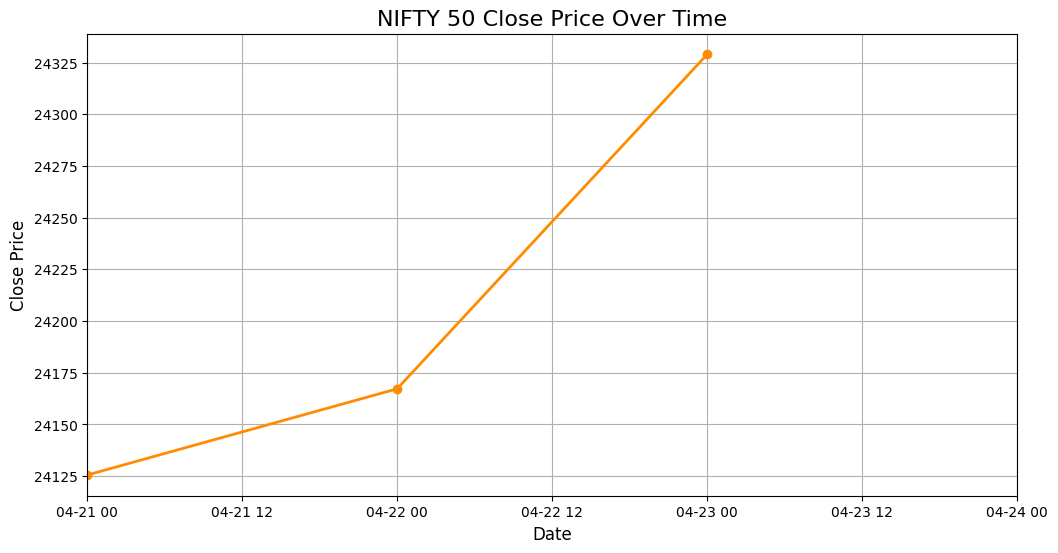

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Load and prepare the data
df = pd.read_csv('nifty_last_week_cleaned.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# 2. Set up the figure
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('NIFTY 50 Close Price Over Time', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price', fontsize=12)
ax.grid(True)

# 3. Create the line object (dark-orange line with circular markers)
line, = ax.plot([], [], color='darkorange', marker='o', markersize=6, linewidth=2)

# 4. Define limits
ax.set_xlim(df['Date'].min(), df['Date'].max())
ax.set_ylim(df['Close'].min() - 10, df['Close'].max() + 10)

# 5. Init and update functions
def init():
    line.set_data([], [])
    return (line,)

def update(frame):
    line.set_data(df['Date'][:frame], df['Close'][:frame])
    return (line,)

# 6. Build the animation
ani = animation.FuncAnimation(
    fig, update, frames=len(df), init_func=init,
    blit=True, interval=400
)

# Option A: Save as GIF (requires pillow)
# ---------------------------------------
# pip install pillow
ani.save('nifty_animation.gif', writer='pillow', fps=2)
print("✅ Saved animation to nifty_animation.gif")

# Option B: Embed in a Jupyter notebook
# -------------------------------------
# from IPython.display import HTML
# HTML(ani.to_jshtml())


✅ Saved animation to nifty_animation.gif


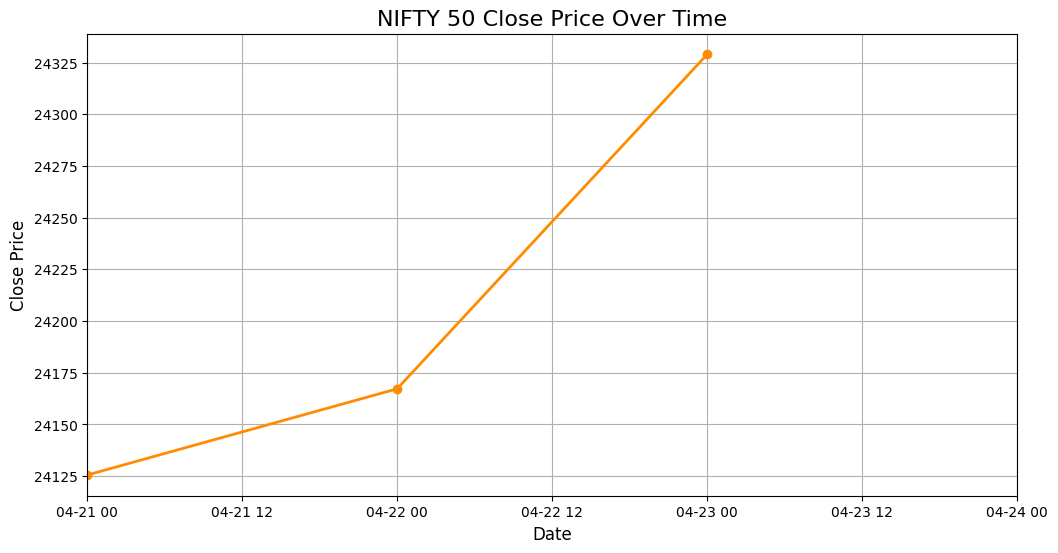

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# 1. Load and prepare the data
df = pd.read_csv('nifty_last_week_cleaned.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# 2. Set up the figure
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_title('NIFTY 50 Close Price Over Time', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Close Price', fontsize=12)
ax.grid(True)

# 3. Create the line object (dark-orange line with circular markers)
line, = ax.plot([], [], color='darkorange', marker='o', markersize=6, linewidth=2)

# 4. Define limits
ax.set_xlim(df['Date'].min(), df['Date'].max())
ax.set_ylim(df['Close'].min() - 10, df['Close'].max() + 10)

# 5. Init and update functions
def init():
    line.set_data([], [])
    return (line,)

def update(frame):
    line.set_data(df['Date'][:frame], df['Close'][:frame])
    return (line,)

# 6. Build the animation
ani = animation.FuncAnimation(
    fig, update, frames=len(df), init_func=init,
    blit=True, interval=400
)

# Option A: Save as GIF (requires pillow)
# ---------------------------------------
# Install pillow if you don't have it: pip install pillow
ani.save('nifty_animation.gif', writer='pillow', fps=2)
print("✅ Saved animation to nifty_animation.gif")
